In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats as stats

import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 12,
    })
from matplotlib.colors import Normalize
import corner

from plot_eos_inference import load_posterior, plot_mr, plot_ml, plot_pressure, plot_pop, corner_plot, get_quantiles, r14_confidence_interval, mtov_confidence_interval, plot_mr_nofill, plot_pop_nofill

# load EOS
m_eos, r_eos, l_eos = np.loadtxt("../../eos/RMF3_MRL.dat", unpack=True)
mtov = m_eos.max()
n_eos, p_eos = np.loadtxt("../../eos/RMF3_cold_beta_lamb.d", unpack=True, usecols=[1,3])

latex_labels={"mu_1": "$\\mu_1$", "mu_2": "$\\mu_2$", "sigma_1": "$\\sigma_1$", "sigma_2": "$\\sigma_2$", "alpha": "$\\alpha$", "m_min": "$m_{\\rm{min}}$", "m_max": "$m_{\\rm{max}}$" }
fontsize=14

def pressure_confidence_interval(posterior):
    x = np.geomspace(0.5, 10, 100) # densities 
    x, quantiles, _ = get_quantiles(x, posterior["densities_EOS"] / 0.16, posterior["pressures_EOS"], posterior["weights"])

    lower = np.interp(3, x, quantiles[:, 0])
    median = np.interp(3, x, quantiles[:, 2])
    upper = np.interp(3, x, quantiles[:, 4])
    plus = upper-median
    minus = median-lower

    return f"{{{median:.0f}}}^{{+{plus:.0f}}}_{{-{minus:.0f}}}"

## narrow ETL

In [3]:
directory = Path("../narrow_ETL")

posterior_gw = load_posterior(directory / "inference_eos" / "gw" / "outdir_gw" / "results.h5")
posterior_mm = load_posterior(directory / "inference_eos" / "mm" / "outdir_mm" / "results.h5")
posterior_mm_full = load_posterior(directory / "inference_eos" / "mm_full" / "outdir_mm" / "results.h5")
posterior_mm_cheat = load_posterior(directory / "inference_eos" / "mm_cheating" / "outdir_mm" / "results.h5")
posterior_gw_source_frame = load_posterior(directory / "inference_eos" / "gw_with_source_frame" / "outdir_gw" / "results.h5")



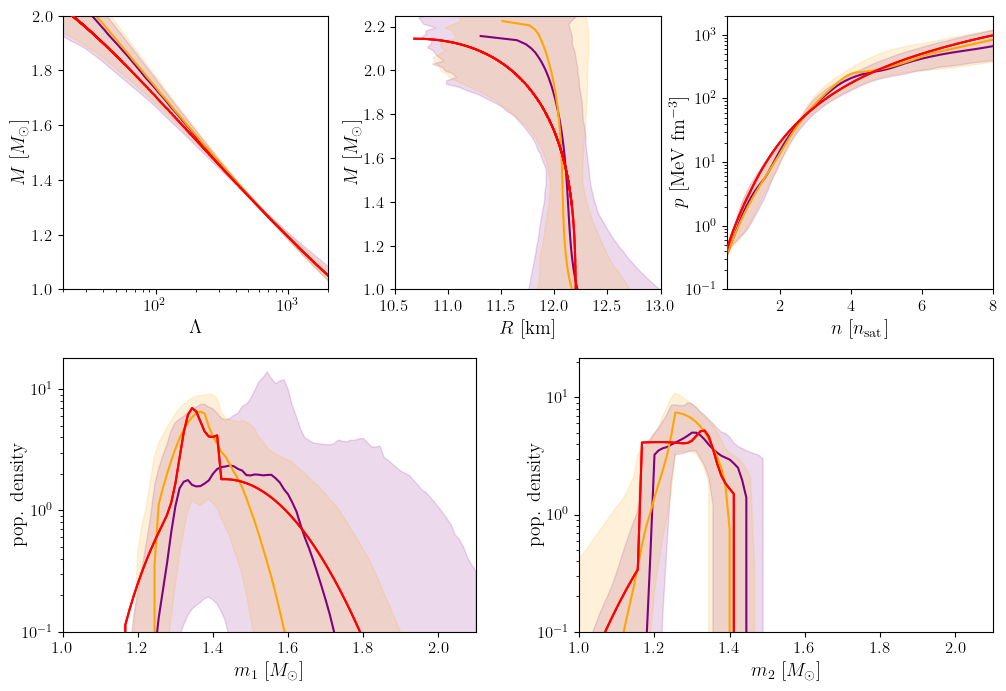

In [33]:
fig = plt.figure(figsize=(12, 8))

outer = fig.add_gridspec(2, 1, hspace=0.25)

# upper: 3 side to side panels
upper = outer[0].subgridspec(1, 3, wspace=0.25)

# lower: 2 side to side panels
lower = outer[1].subgridspec(1, 2, wspace=0.25)

ax_ml= fig.add_subplot(upper[0])
ax_mr = fig.add_subplot(upper[1])
ax_pressure = fig.add_subplot(upper[2])
ax_pop1 = fig.add_subplot(lower[0])
ax_pop2 = fig.add_subplot(lower[1])

plot_ml(ax_ml, posterior_gw, color="purple")
plot_ml(ax_ml, posterior_mm, color="orange")

plot_mr(ax_mr, posterior_gw, color="purple", plot_bestfit=True)
plot_mr(ax_mr, posterior_mm, color="orange", plot_bestfit=True)

plot_pressure(ax_pressure, posterior_gw, color="purple", plot_bestfit=True)
plot_pressure(ax_pressure, posterior_mm, color="orange",)

plot_pop([ax_pop1, ax_pop2], posterior_gw, color="purple")
plot_pop([ax_pop1, ax_pop2], posterior_mm, color="orange")

fig.savefig(
    "../../figures/eos_inference_narrow_ETL.pdf",
    dpi=250,
    bbox_inches="tight"
)

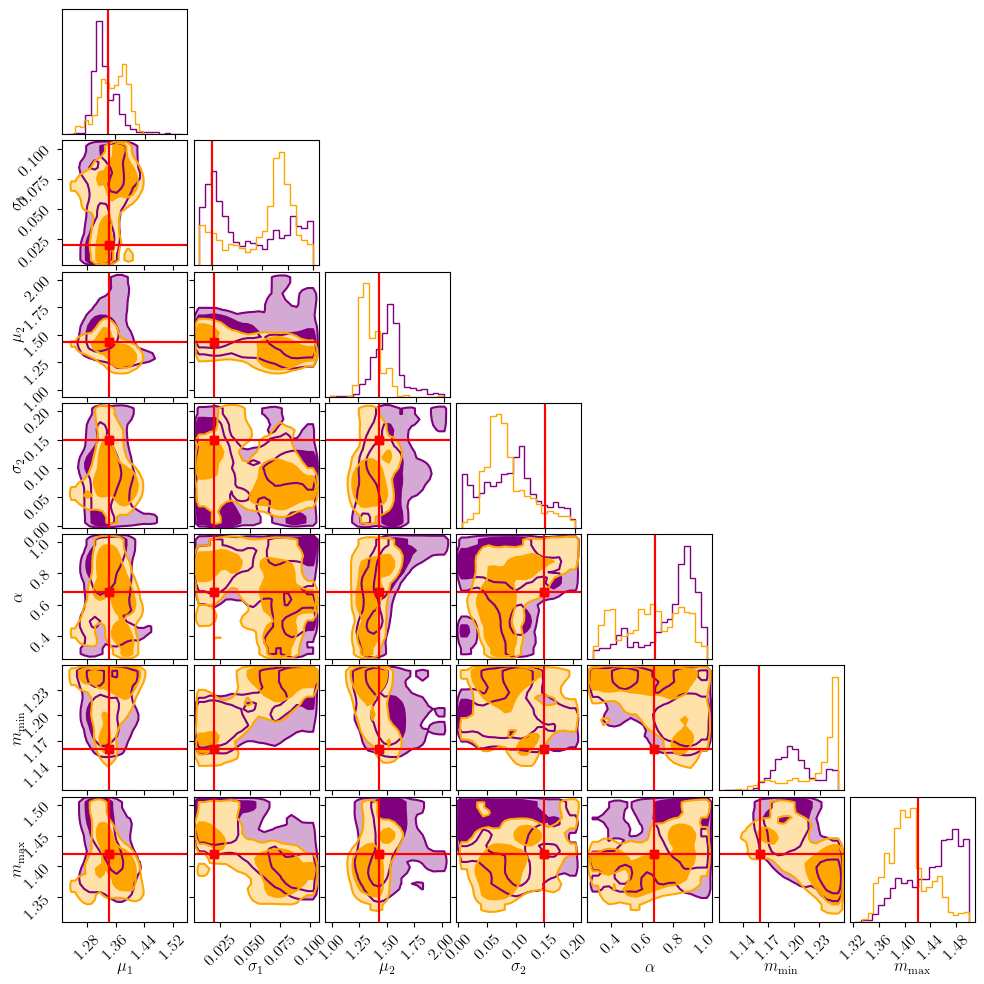

In [4]:
fig = corner_plot(posterior_gw, ["mu_1", "sigma_1", "mu_2", "sigma_2", "alpha", "m_min", "m_max"])
fig = corner_plot(posterior_mm, ["mu_1", "sigma_1", "mu_2", "sigma_2", "alpha", "m_min", "m_max"], fig, color="orange")

(0.0, 0.5)

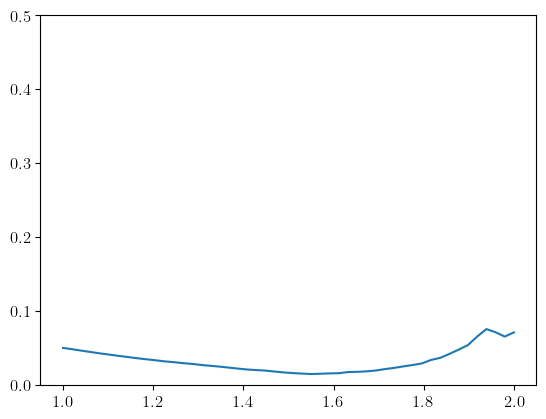

In [5]:
xs, quantiles, _ = get_quantiles(np.linspace(1, 2, 50), posterior_gw["masses_EOS"], posterior_gw["radii_EOS"], posterior_gw["weights"])
plt.plot(xs, (quantiles[:, 2] / quantiles[:, 0] - 1))
plt.ylim((0, 0.5))

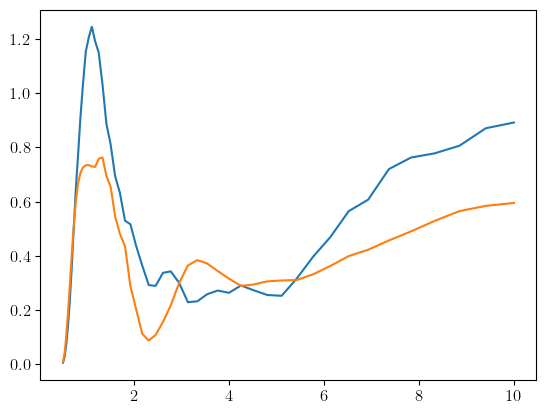

In [19]:
xs, quantiles, _ = get_quantiles(np.geomspace(0.5, 10, 50), posterior_gw["densities_EOS"]/0.16, posterior_gw["pressures_EOS"], posterior_gw["weights"])
plt.plot(xs, (quantiles[:, 2] / quantiles[:, 0])-1)
plt.plot(xs, (quantiles[:, 4] / quantiles[:, 2])-1)

In [6]:
print(r14_confidence_interval(posterior_gw))
print(r14_confidence_interval(posterior_mm))

{12.15}^{+0.23}_{-0.25}
{12.13}^{+0.17}_{-0.19}


In [7]:
print(mtov_confidence_interval(posterior_gw))
print(mtov_confidence_interval(posterior_mm))

{2.16}^{+0.19}_{-0.21}
{2.22}^{+0.31}_{-0.24}


In [25]:
print(pressure_confidence_interval(posterior_gw))
print(pressure_confidence_interval(posterior_mm))

{65}^{+21}_{-15}
{68}^{+22}_{-14}


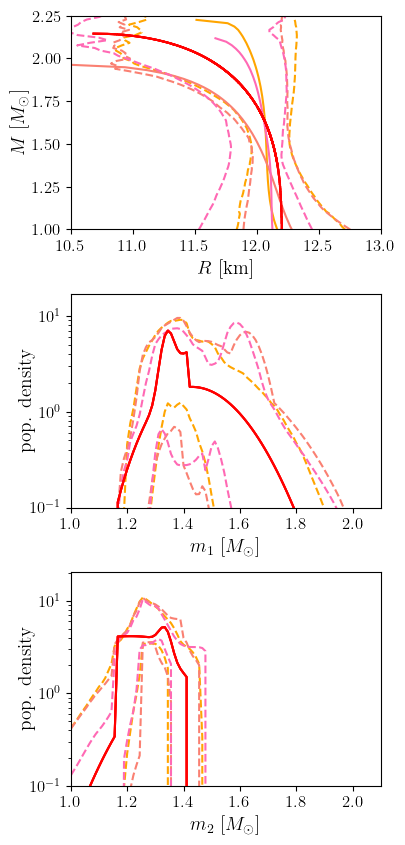

In [4]:

fig, ax = plt.subplots(3, 1, figsize=(4, 10))
fig.subplots_adjust(hspace=0.3)

plot_mr_nofill(ax[0], posterior_mm, color="orange")
plot_mr_nofill(ax[0], posterior_mm_full, color="salmon")
plot_mr_nofill(ax[0], posterior_mm_cheat, color="hotpink")

plot_pop_nofill(ax[1:], posterior_mm, color="orange")
plot_pop_nofill(ax[1:], posterior_mm_full, color="salmon")
plot_pop_nofill(ax[1:], posterior_mm_cheat, color="hotpink")

fig.savefig("../../figures/eos_inference_different_mm.pdf", dpi=250, bbox_inches="tight")


## wide ETL

In [ ]:
directory = Path("../wide_ETL")

posterior_gw = load_posterior(directory / "inference_eos" / "gw" / "outdir_gw" / "results.h5")
posterior_mm = load_posterior(directory / "inference_eos" / "mm" / "outdir_mm" / "results.h5")

/home/koehn1/miniconda3/envs/nmma_x_fiesta/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1601: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


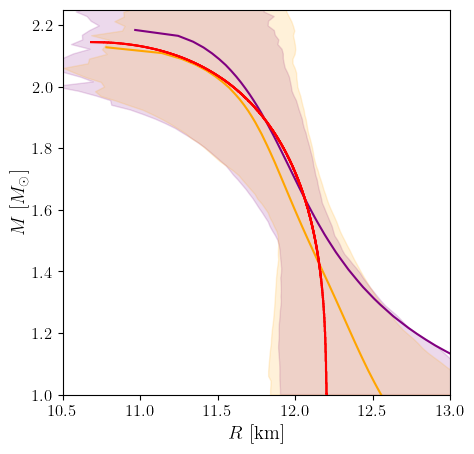

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

plot_mr(ax, posterior_gw, color="purple")
plot_mr(ax, posterior_mm, color="orange")

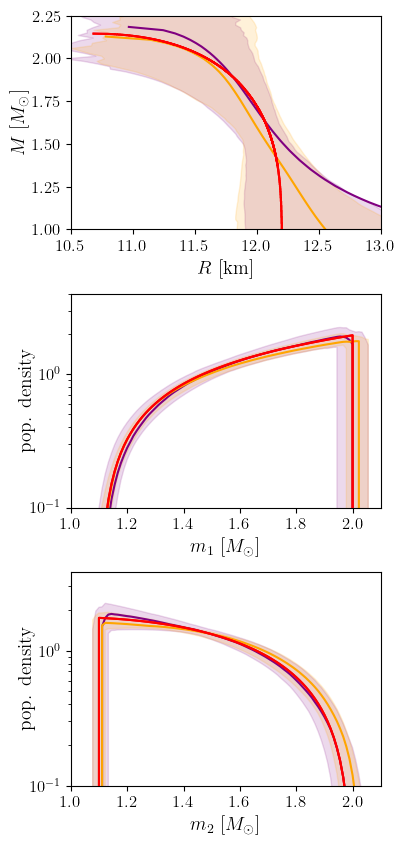

In [36]:
fig, ax = plt.subplots(3, 1, figsize=(4, 10))
fig.subplots_adjust(hspace=0.3)

plot_mr(ax[0], posterior_gw, color="purple")
plot_mr(ax[0], posterior_mm, color="orange")

plot_pop(ax[1:], posterior_gw, color="purple")
plot_pop(ax[1:], posterior_mm, color="orange")

fig.savefig("../../figures/eos_inference_wide_ETL.pdf", dpi=250, bbox_inches="tight")

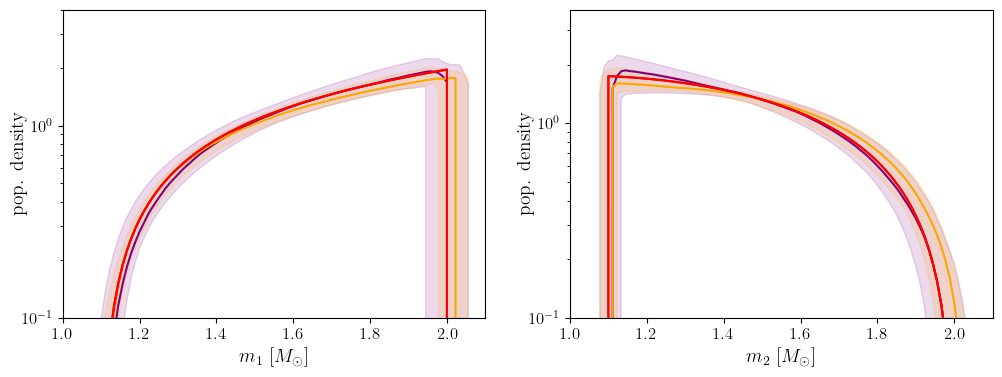

In [28]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

plot_pop(ax, posterior_gw, color="purple", plot_bestfit=False)
plot_pop(ax, posterior_mm, color="orange", plot_bestfit=False)

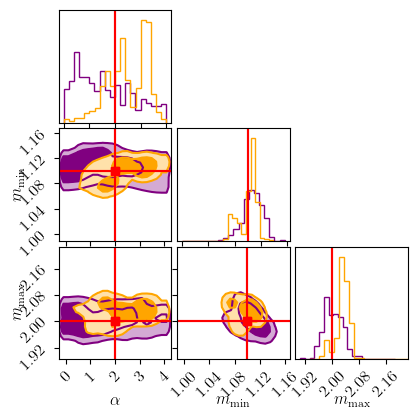

In [29]:
fig = corner_plot(posterior_gw, ["alpha", "m_min", "m_max"])
fig = corner_plot(posterior_mm, ["alpha", "m_min", "m_max"], fig, color="orange")

In [24]:
print(r14_confidence_interval(posterior_gw))
print(r14_confidence_interval(posterior_mm))

{12.16}^{+0.25}_{-0.25}
{12.17}^{+0.25}_{-0.29}


/home/koehn1/miniconda3/envs/nmma_x_fiesta/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1601: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


In [17]:
print(pressure_confidence_interval(posterior_gw))
print(pressure_confidence_interval(posterior_mm))

{65}^{+21}_{-15}
{68}^{+22}_{-14}


(11.5, 13.0)

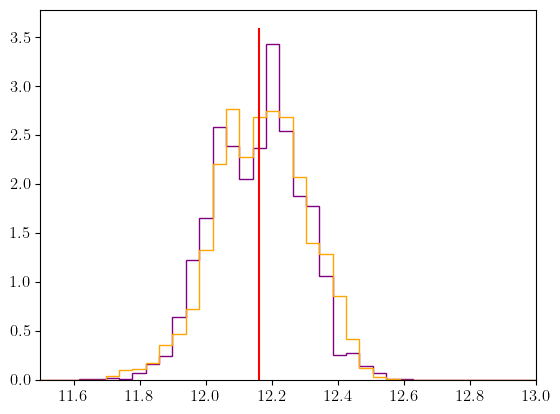

In [28]:
r14_gw = np.array([np.interp(1.4, posterior_gw["masses_EOS"][j], posterior_gw["radii_EOS"][j]) for j in range(7000)])
r14_mm = np.array([np.interp(1.4, posterior_mm["masses_EOS"][j], posterior_mm["radii_EOS"][j]) for j in range(7000)])

bins = np.linspace(10, 14, 100)
plt.hist(r14_gw, color="purple", density=True, histtype="step", bins=bins, weights=posterior_gw["weights"])
plt.hist(r14_mm, color="orange", density=True, histtype="step", bins=bins, weights=posterior_mm["weights"])
plt.vlines([np.interp(1.4, m_eos, r_eos)], *plt.gca().get_ylim(), color="red")
plt.xlim(11.5, 13.0)

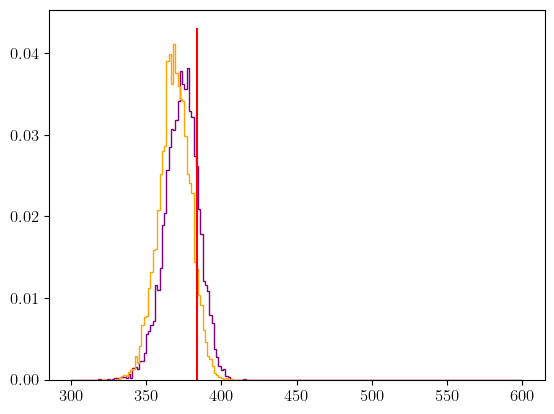

In [23]:
l14_gw = np.array([np.interp(1.4, posterior_gw["masses_EOS"][j], posterior_gw["lambdas_EOS"][j]) for j in range(7000)])
l14_mm = np.array([np.interp(1.4, posterior_mm["masses_EOS"][j], posterior_mm["lambdas_EOS"][j]) for j in range(7000)])

bins = np.linspace(300, 600, 200)
plt.hist(l14_gw, color="purple", density=True, histtype="step", bins=bins)
plt.hist(l14_mm, color="orange", density=True, histtype="step", bins=bins)
plt.vlines([np.interp(1.4, m_eos, l_eos)], *plt.gca().get_ylim(), color="red")

# Narrow ETT

In [46]:
directory = Path("../narrow_ETT")

posterior_gw = load_posterior(directory / "inference_eos" / "gw" / "outdir_gw" / "results.h5")
posterior_mm = load_posterior(directory / "inference_eos" / "mm" / "outdir_mm" / "results.h5")
posterior_mm_full = load_posterior(directory / "inference_eos" / "mm_full" / "outdir_mm" / "results.h5")
posterior_mm_cheating = load_posterior(directory / "inference_eos" / "mm_cheating" / "outdir_mm" / "results.h5")


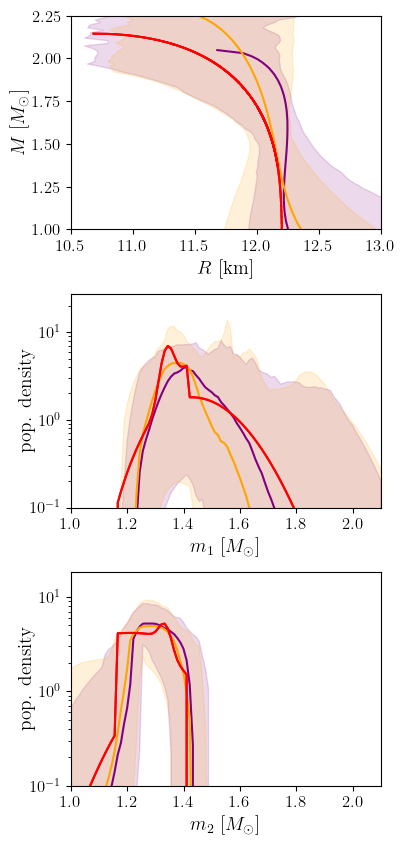

In [38]:
fig, ax = plt.subplots(3, 1, figsize=(4, 10))
fig.subplots_adjust(hspace=0.3)

plot_mr(ax[0], posterior_gw, color="purple")
plot_mr(ax[0], posterior_mm, color="orange")

plot_pop(ax[1:], posterior_gw, color="purple")
plot_pop(ax[1:], posterior_mm, color="orange")

fig.savefig("../../figures/eos_inference_narrow_ETT.pdf", dpi=250, bbox_inches="tight")

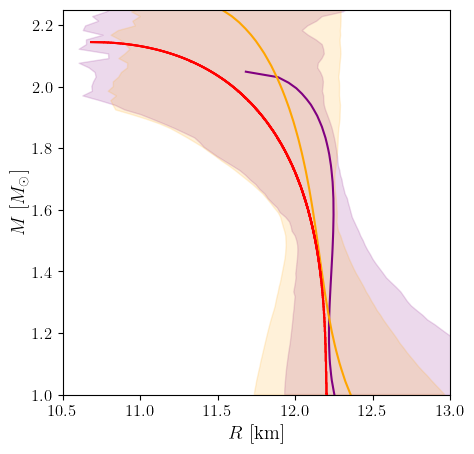

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(5, 5))

plot_mr(ax, posterior_gw, color="purple", plot_bestfit=True)
plot_mr(ax, posterior_mm, color="orange", plot_bestfit=True)

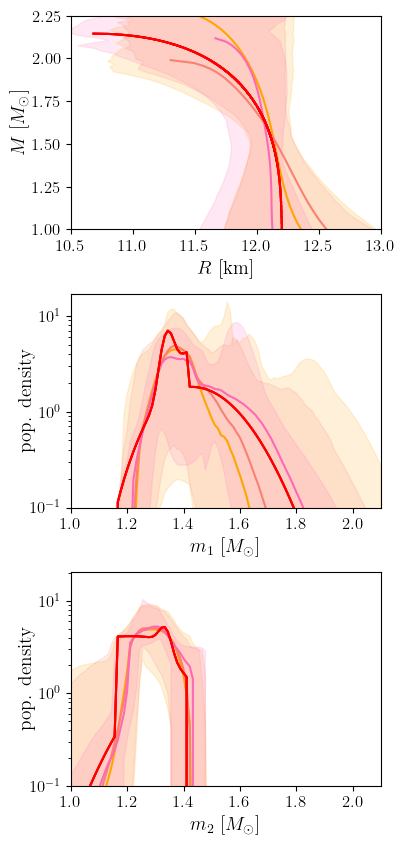

In [47]:
fig, ax = plt.subplots(3, 1, figsize=(4, 10))
fig.subplots_adjust(hspace=0.3)

plot_mr(ax[0], posterior_mm, color="orange")
plot_mr(ax[0], posterior_mm_full, color="salmon")
plot_mr(ax[0], posterior_mm_cheat, color="hotpink")

plot_pop(ax[1:], posterior_mm, color="orange")
plot_pop(ax[1:], posterior_mm_full, color="salmon")
plot_pop(ax[1:], posterior_mm_cheat, color="hotpink")

## wide ETT

In [39]:
directory = Path("../wide_ETT")

posterior_gw = load_posterior(directory / "inference_eos" / "gw" / "outdir_gw" / "results.h5")
posterior_mm = load_posterior(directory / "inference_eos" / "mm" / "outdir_mm" / "results.h5")

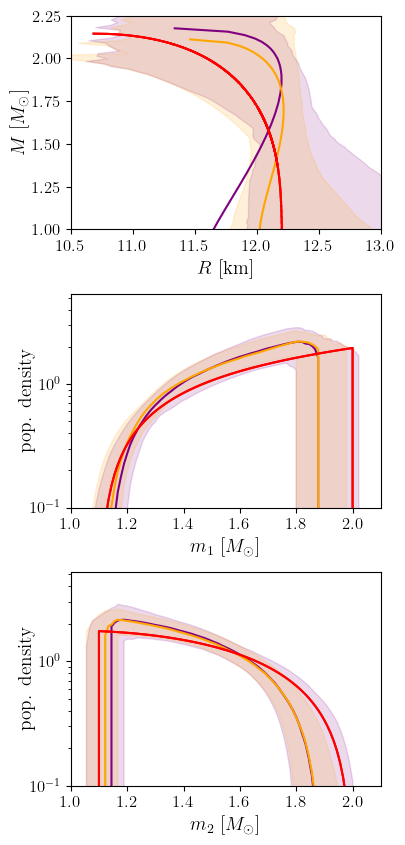

In [40]:
fig, ax = plt.subplots(3, 1, figsize=(4, 10))
fig.subplots_adjust(hspace=0.3)

plot_mr(ax[0], posterior_gw, color="purple")
plot_mr(ax[0], posterior_mm, color="orange")

plot_pop(ax[1:], posterior_gw, color="purple")
plot_pop(ax[1:], posterior_mm, color="orange")

fig.savefig("../../figures/eos_inference_wide_ETT.pdf", dpi=250, bbox_inches="tight")

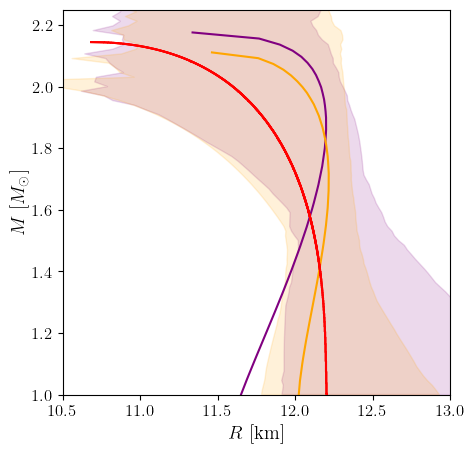

In [41]:
fig, ax = plt.subplots(1,1, figsize=(5, 5))

plot_mr(ax, posterior_gw, color="purple", plot_bestfit=True)
plot_mr(ax, posterior_mm, color="orange", plot_bestfit=True)

(array([1.000e+00, 0.000e+00, 2.000e+00, 6.000e+00, 5.900e+01, 1.860e+02,
        7.520e+02, 2.448e+03, 3.063e+03, 4.830e+02]),
 array([-319.88609808, -317.4779434 , -315.06978872, -312.66163404,
        -310.25347937, -307.84532469, -305.43717001, -303.02901533,
        -300.62086065, -298.21270597, -295.8045513 ]),
 <BarContainer object of 10 artists>)

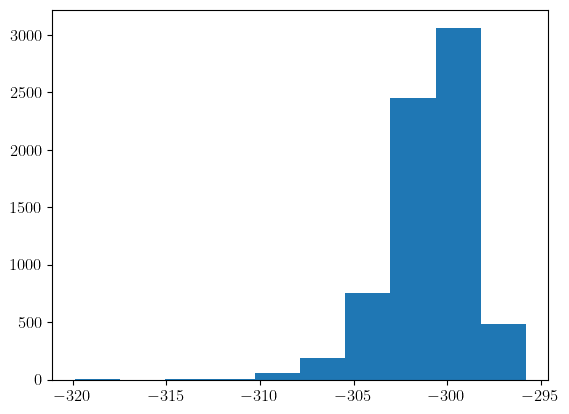

In [42]:
plt.hist(posterior_mm["log_prob"])